## Importing Modules

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from IPython.display import Image
from dotenv import load_dotenv,find_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import os
import operator

load_dotenv(find_dotenv())

True

In [2]:

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

print(GROQ_API_KEY[:10])  # Just to verify it's loaded

gsk_3oeoml


In [3]:
client = Groq(api_key=GROQ_API_KEY)
llm = ChatGroq(model="openai/gpt-oss-120b")

## Simple Parallel Workflow

In [6]:
class BatsmanState(TypedDict):
    """State of the Batman conversation."""

    runs: int
    balls_faced: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary : float
    boundary_percentage: float

    summary : str

In [7]:
def calculate_strike_rate(state: BatsmanState):
    return {
        "strike_rate": (state["runs"] / state["balls_faced"]) * 100
    }


def calculate_balls_per_boundary(state: BatsmanState):
    total_boundaries = state["fours"] + state["sixes"]

    return {
        "balls_per_boundary":
            state["balls_faced"] / total_boundaries
            if total_boundaries else float("inf")
    }

def calculate_boundary_percentage(state: BatsmanState):
    total_boundaries = state["fours"] + state["sixes"]

    return {
        "boundary_percentage":
            (total_boundaries / state["balls_faced"]) * 100
            if state["balls_faced"] else 0
    }


def summary(state: BatsmanState):
    return {
        "summary": (
            f"Runs: {state['runs']}, "
            f"Balls Faced: {state['balls_faced']}, "
            f"Fours: {state['fours']}, "
            f"Sixes: {state['sixes']}, "
            f"Strike Rate: {state['strike_rate']:.2f}, "
            f"Balls per Boundary: {state['balls_per_boundary']:.2f}, "
            f"Boundary Percentage: {state['boundary_percentage']:.2f}%"
        )
    }

In [8]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate",calculate_strike_rate)

graph.add_node("calculate_balls_per_boundary",calculate_balls_per_boundary)

graph.add_node("calculate_boundary_percentage",calculate_boundary_percentage)
graph.add_node("summary",summary)



graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_balls_per_boundary")   
graph.add_edge(START, "calculate_boundary_percentage")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_balls_per_boundary", "summary")
graph.add_edge("calculate_boundary_percentage", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()

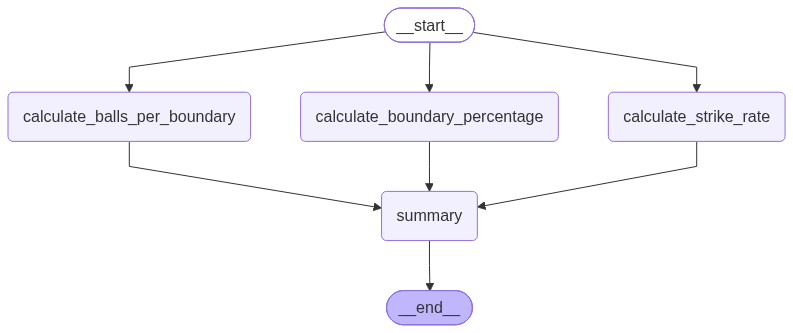

In [9]:
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
initial_state = {
    "runs": 100,
    "balls_faced": 60,
    "fours": 10,
    "sixes": 5,
   
}
final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls_faced': 60, 'fours': 10, 'sixes': 5, 'strike_rate': 166.66666666666669, 'balls_per_boundary': 4.0, 'boundary_percentage': 25.0, 'summary': 'Runs: 100, Balls Faced: 60, Fours: 10, Sixes: 5, Strike Rate: 166.67, Balls per Boundary: 4.00, Boundary Percentage: 25.00%'}


## LLM workflow

In [64]:
llm_cot = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
) ## clarity of thought
llm_doa = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
) ## depth of analysis
llm_language = ChatGroq(
    model="qwen/qwen3.6-27b",
    temperature=0
) ## language quality and fluency

llm_summary = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
) ## overall summary and synthesis of the analysis

In [65]:
class EvaluationSchema(BaseModel):
    """Schema for the evaluation of the analysis."""

    feedback : str = Field(description="Feedback on the analysis provided by the model, including clarity, depth, and language quality.")
    score : float = Field(description="A score between 0 and 10 representing the overall quality of the analysis, where 10 is perfect and 0 is poor.",ge=0, le=10)

In [66]:
structured_model = llm_summary.with_structured_output(EvaluationSchema)


structured_cot = llm_cot.with_structured_output(EvaluationSchema)
structured_doa = llm_doa.with_structured_output(EvaluationSchema)
structured_language = llm_language.with_structured_output(EvaluationSchema)

In [ ]:
class UPSCSTATE(TypedDict):
    """State of the UPSC conversation."""
    eassy: str
    clarity_of_thought: str
    depth_of_analysis: str
    language_quality: str

    over_all_feedback: str
    individual_scores: Annotated[list[dict],operator.add]
    avg_score: float

    

In [77]:
def evaluate_language(state: UPSCSTATE):
    prompt = f"Evaluate the language quality of the following essay:\n{state['eassy']}\nProvide feedback and a score between 0 and 10."
    response = structured_language.invoke(prompt)
    return {
        "language_quality": response.feedback,
        "individual_scores": [{"category": "language_quality", "score": response.score}]
    }

def evaluate_analysis(state: UPSCSTATE):
    prompt = f"Evaluate the depth of analysis of the following essay:\n{state['eassy']}\nProvide feedback and a score between 0 and 10."
    response = structured_doa.invoke(prompt)
    return {
        "depth_of_analysis": response.feedback,
        "individual_scores": [{"category": "depth_of_analysis", "score": response.score}]
    }

def evaluate_thought(state: UPSCSTATE):
    prompt = f"Evaluate the clarity of thought of the following essay:\n{state['eassy']}\nProvide feedback and a score between 0 and 10."
    response = structured_cot.invoke(prompt)
    return {
        "clarity_of_thought": response.feedback,
        "individual_scores": [{"category": "clarity_of_thought", "score": response.score}]
    }


def final_evaluation(state: UPSCSTATE):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_quality"]} \n depth of analysis feedback - {state["depth_of_analysis"]} \n clarity of thought feedback - {state["clarity_of_thought"]}'
    overall_feedback = llm_summary.invoke(prompt).content

    # avg calculate
    avg_score = 0
    for i in state["individual_scores"]:
        avg_score += i["score"]
    avg_score = avg_score / len(state["individual_scores"]) 

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}


In [78]:
graph = StateGraph(UPSCSTATE)

graph.add_node("clarity_of_thought", evaluate_thought)
graph.add_node("depth_of_analysis", evaluate_analysis)
graph.add_node("language_quality", evaluate_language)
graph.add_node("over_all_feedback", final_evaluation)


# edges
graph.add_edge(START, 'language_quality')
graph.add_edge(START, 'depth_of_analysis')
graph.add_edge(START, 'clarity_of_thought')

graph.add_edge('language_quality', 'over_all_feedback')
graph.add_edge('depth_of_analysis', 'over_all_feedback')
graph.add_edge('clarity_of_thought', 'over_all_feedback')

graph.add_edge('over_all_feedback', END)

workflow = graph.compile()

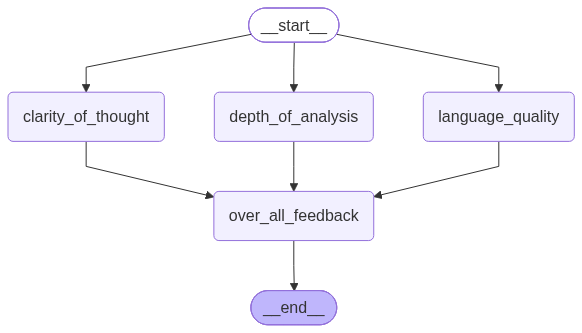

In [74]:
Image(workflow.get_graph().draw_mermaid_png())

In [79]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [80]:
intial_state = {
    'eassy': essay2
}

workflow.invoke(intial_state)

{'eassy': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n

In [81]:
essay_3 = '''
**Role of India in Artificial Intelligence: From Technology Consumer to Global Leader**

Artificial Intelligence (AI) is redefining economies, governance, and human progress. As the world's largest democracy with a vibrant digital ecosystem, India stands at a historic crossroads. Its role is not merely to adopt AI but to shape its future through innovation, inclusivity, and ethical leadership.

India possesses unique strengths. With over a billion digital users, a thriving startup ecosystem, and globally recognized IT talent, it has the ingredients to become an AI powerhouse. Government initiatives such as the IndiaAI Mission, Digital India, and Aadhaar-enabled digital infrastructure have created a strong foundation for AI-driven governance. From precision agriculture and smart healthcare to adaptive education and disaster management, AI has the potential to solve India's developmental challenges at an unprecedented scale.

However, India's true contribution lies beyond technological advancement. The nation can pioneer **"AI for All"** by ensuring that innovation reaches villages, farmers, students, and small businesses. AI-powered translation tools can bridge linguistic diversity, while predictive healthcare can make quality medical services accessible to remote populations. Thus, AI becomes an instrument of social justice rather than merely economic growth.

Yet, rapid AI adoption raises concerns regarding privacy, algorithmic bias, unemployment, and misinformation. India must therefore champion a balanced framework that encourages innovation while safeguarding constitutional values. Investments in digital literacy, reskilling, transparent AI governance, and indigenous research are essential to building public trust.

Globally, India can emerge as the voice of the Global South by advocating equitable access to AI technologies and responsible international standards. Just as India led the world in affordable digital public infrastructure, it can now lead in developing ethical, inclusive, and human-centric AI.

In conclusion, India's role in AI is not confined to writing algorithms but to writing the future of humanity. If guided by innovation, inclusiveness, and integrity, India can transform AI from a tool of automation into a force for empowerment. **The century of Artificial Intelligence can also become the century of India, provided technology remains rooted in human values.**


'''

In [82]:
intial_state = {
    'eassy': essay_3
}

workflow.invoke(intial_state)

{'eassy': '\n**Role of India in Artificial Intelligence: From Technology Consumer to Global Leader**\n\nArtificial Intelligence (AI) is redefining economies, governance, and human progress. As the world\'s largest democracy with a vibrant digital ecosystem, India stands at a historic crossroads. Its role is not merely to adopt AI but to shape its future through innovation, inclusivity, and ethical leadership.\n\nIndia possesses unique strengths. With over a billion digital users, a thriving startup ecosystem, and globally recognized IT talent, it has the ingredients to become an AI powerhouse. Government initiatives such as the IndiaAI Mission, Digital India, and Aadhaar-enabled digital infrastructure have created a strong foundation for AI-driven governance. From precision agriculture and smart healthcare to adaptive education and disaster management, AI has the potential to solve India\'s developmental challenges at an unprecedented scale.\n\nHowever, India\'s true contribution lies 